In [30]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.inspection import permutation_importance
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("cardio_data_cleaned(IQR).csv")

In [3]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Evaluation

In [5]:
linear_model = joblib.load("svm_linear_model.joblib")
poly_model_1 = joblib.load("svm_poly_model_1.joblib")
poly_model_01 = joblib.load("svm_poly_model_01.joblib")
poly_model_001 = joblib.load("svm_poly_model_001.joblib")

In [6]:
linear_predictions = linear_model.predict(X_test)
poly_predictions_1 = poly_model_1.predict(X_test)
poly_predictions_01 = poly_model_01.predict(X_test)
poly_predictions_001 = poly_model_001.predict(X_test)

In [7]:
cm_linear = confusion_matrix(y_test, linear_predictions)
cm_poly_1 = confusion_matrix(y_test, poly_predictions_1)
cm_poly_01 = confusion_matrix(y_test, poly_predictions_01)
cm_poly_001 = confusion_matrix(y_test, poly_predictions_001)

In [8]:
cr_linear = classification_report(y_test, linear_predictions, target_names=['No disease', 'Disease'])
print(cr_linear)

              precision    recall  f1-score   support

  No disease       0.69      0.81      0.74      6345
     Disease       0.76      0.62      0.68      6156

    accuracy                           0.72     12501
   macro avg       0.72      0.72      0.71     12501
weighted avg       0.72      0.72      0.71     12501



In [9]:
cr_poly_1 = classification_report(y_test, poly_predictions_1, target_names=['No disease', 'Disease'])
print(cr_poly_1)

              precision    recall  f1-score   support

  No disease       0.66      0.85      0.74      6345
     Disease       0.78      0.55      0.65      6156

    accuracy                           0.70     12501
   macro avg       0.72      0.70      0.70     12501
weighted avg       0.72      0.70      0.70     12501



In [10]:
cr_poly_01 = classification_report(y_test, poly_predictions_01, target_names=['No disease', 'Disease'])
print(cr_poly_01)

              precision    recall  f1-score   support

  No disease       0.66      0.85      0.74      6345
     Disease       0.78      0.55      0.65      6156

    accuracy                           0.70     12501
   macro avg       0.72      0.70      0.69     12501
weighted avg       0.72      0.70      0.70     12501



In [11]:
cr_poly_001 = classification_report(y_test, poly_predictions_001, target_names=['No disease', 'Disease'])
print(cr_poly_001)

              precision    recall  f1-score   support

  No disease       0.66      0.87      0.75      6345
     Disease       0.79      0.53      0.64      6156

    accuracy                           0.70     12501
   macro avg       0.73      0.70      0.69     12501
weighted avg       0.72      0.70      0.69     12501



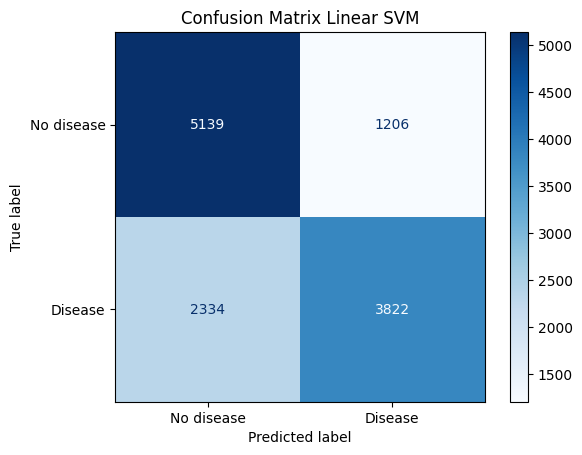

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_linear, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix Linear SVM')
plt.show()

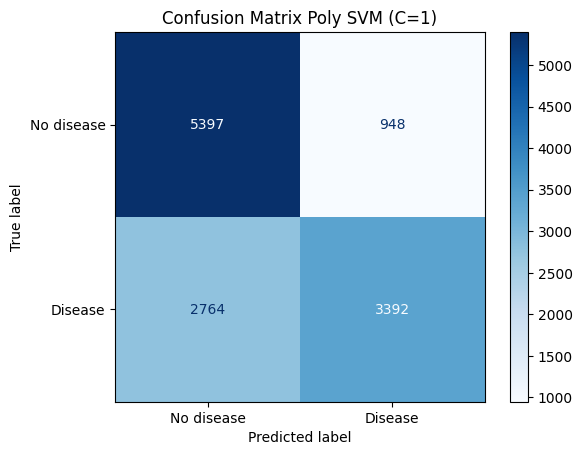

In [13]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_1, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix Poly SVM (C=1)')
plt.show()

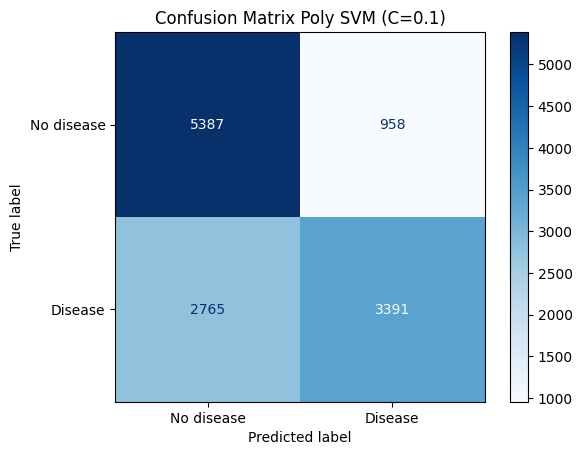

In [14]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_01, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix Poly SVM (C=0.1)')
plt.show()

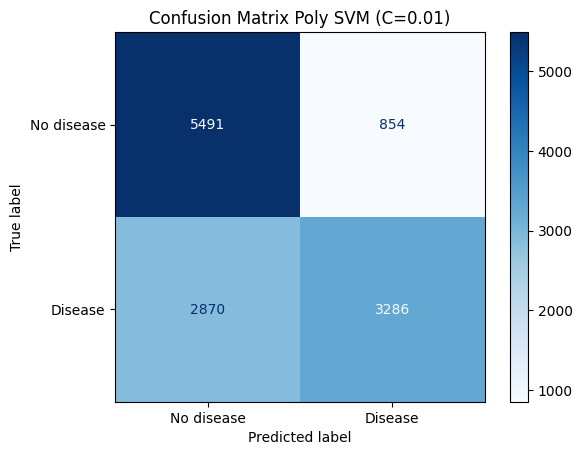

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_poly_001, display_labels=['No disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix Poly SVM (C=0.01)')
plt.show()

## Explaining the linear kernel SVM model

In [16]:
!pip install shap

In [17]:
!pip install lime

In [18]:
import shap
import lime
import lime.lime_tabular

In [19]:
background = shap.kmeans(X_train, 50)
explainer = shap.KernelExplainer(linear_model.decision_function, background)

X_to_explain = shap.sample(X_test, 100)
shap_values = explainer.shap_values(X_to_explain)

  0%|          | 0/100 [00:00<?, ?it/s]

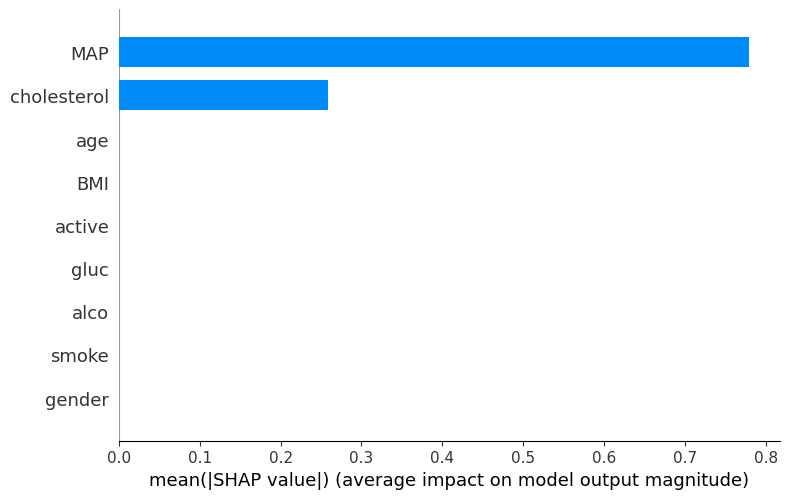

In [21]:
figure = plt.figure()
shap.summary_plot(shap_values, X_to_explain, plot_type='bar')

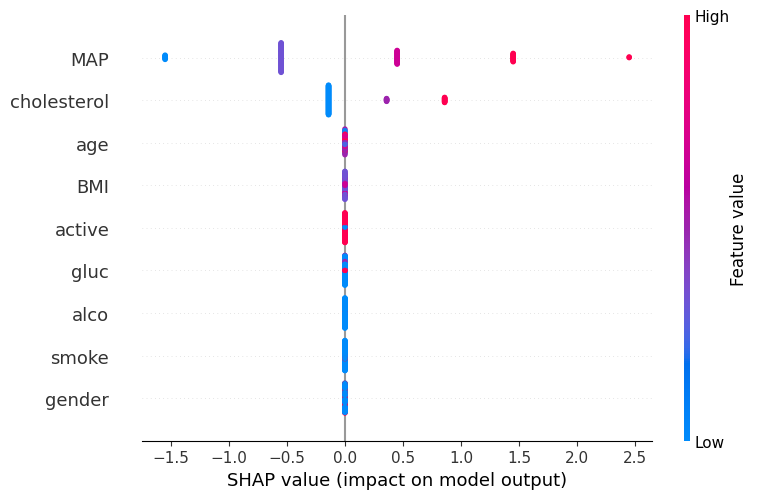

In [24]:
shap.summary_plot(shap_values, X_to_explain)

In [25]:
result = permutation_importance(
    linear_model, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='accuracy'
)

importances = pd.Series(result.importances_mean, index=X_test.columns).sort_values(ascending=False)

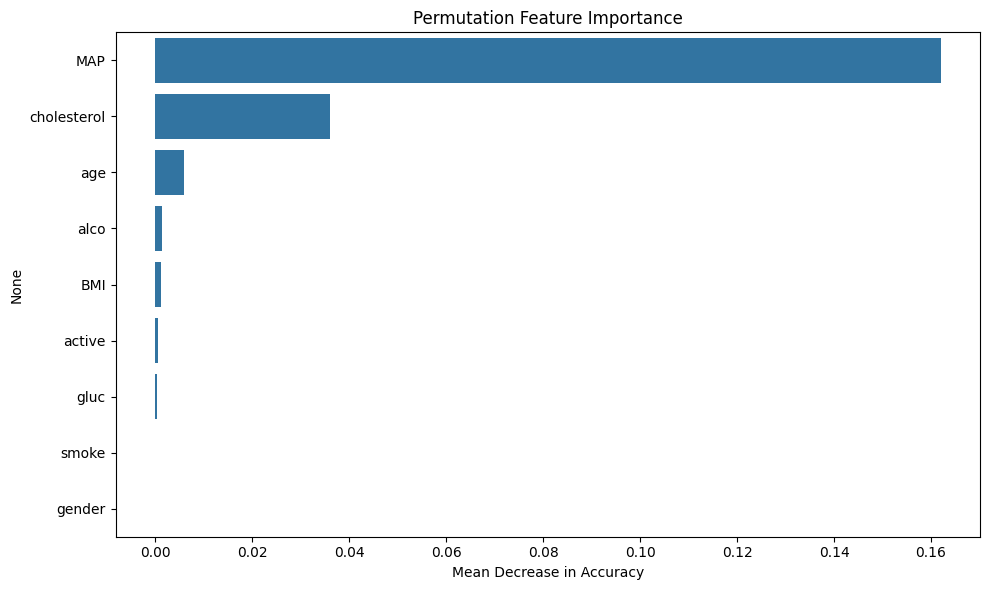

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Permutation Feature Importance")
plt.xlabel("Mean Decrease in Accuracy")
plt.tight_layout()
plt.show()

In [27]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_test.to_numpy(),
    feature_names=X_test.columns.to_list(),
    class_names=['No Disease', 'Disease'],
    mode='classification',
)

In [39]:
def predict_proba(observation):
  prediction = linear_model.decision_function(observation)
  probability = 1 / (1 + np.exp(-prediction))

  if probability.ndim == 1:
      probability = probability.reshape(-1, 1)

  return np.hstack([1 - probability, probability])

In [40]:
predict_proba(X_test.iloc[0:1, :])

array([[0.73091335, 0.26908665]])

In [41]:
instance_idx = 10
exp = explainer.explain_instance(
    data_row=X_test.iloc[instance_idx, :],
    predict_fn=predict_proba
)

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

In [42]:
y_test.iloc[instance_idx]

np.int64(1)

In [43]:
exp.show_in_notebook(show_table=True, show_all=False)

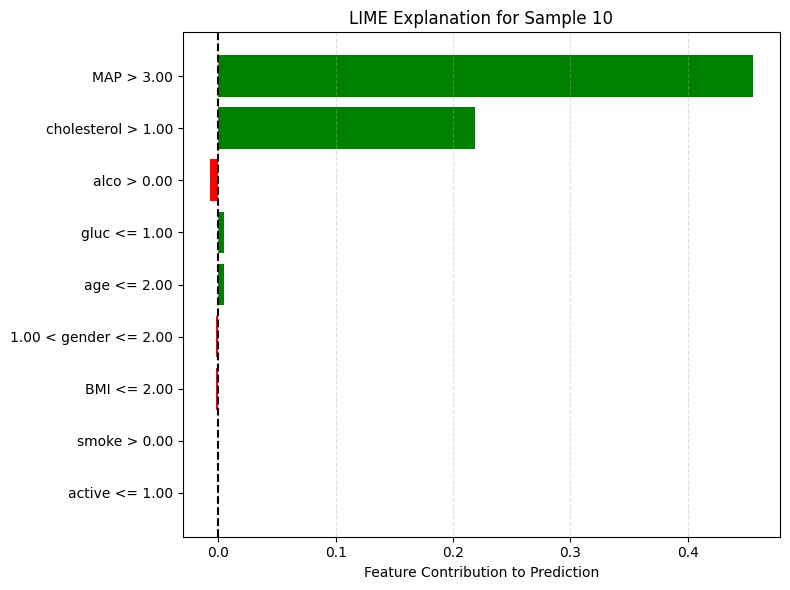

In [44]:
exp_list = exp.as_list(label=1)[::-1]
features = [item[0] for item in exp_list]
weights = [item[1] for item in exp_list]

plt.figure(figsize=(8, 6))
bars = plt.barh(features, weights, color=['green' if w > 0 else 'red' for w in weights])
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel("Feature Contribution to Prediction")
plt.title(f"LIME Explanation for Sample {instance_idx}", loc='center')
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.show()